# Train ResNet50 with FishFresh Datasets


## 1) PATH

In [1]:
# ==== PATH CONFIG: works both locally and on Kaggle ====
from pathlib import Path
import os

def is_kaggle():
    try:
        return ("KAGGLE_URL_BASE" in os.environ) or Path("/kaggle/input").exists()
    except Exception:
        return False

if is_kaggle():
    # On Kaggle: write models/logs into /kaggle/working ('.')
    MODEL_DIR = Path(".")
    root_input = Path("/kaggle/input")
    candidate = None
    if root_input.exists():
        for p in root_input.iterdir():
            if not p.is_dir():
                continue
            # Pick the first dataset that looks like ours
            if (p / "_raw").exists() or (p / "datasets" / "train").exists():
                candidate = p
                break
    if candidate is None:
        raise SystemExit(
            "Could not auto-locate a dataset under /kaggle/input.\n"
            "Attach a dataset that contains either an '_raw' folder or 'datasets/train'."
        )
    DATASET_ROOT = candidate
else:
    # Local machine: prefer 'model/' if it looks like a project root
    cwd = Path.cwd()
    if (cwd / "model" / "_raw").exists() or (cwd / "model" / "datasets" / "train").exists():
        MODEL_DIR = cwd / "model"
    elif (cwd / "_raw").exists() or (cwd / "datasets" / "train").exists():
        MODEL_DIR = cwd
    else:
        MODEL_DIR = cwd
    DATASET_ROOT = MODEL_DIR

print("Running on Kaggle   :", is_kaggle())
print("MODEL_DIR (outputs) :", MODEL_DIR.resolve())
print("DATASET_ROOT        :", DATASET_ROOT.resolve())


Running on Kaggle   : True
MODEL_DIR (outputs) : /kaggle/working
DATASET_ROOT        : /kaggle/input/fishfresh-complete-datasets


## 2) Auto Split _raw to dataset folder

In [2]:
# ==== AUTO-SPLIT _raw INTO datasets/{train,validation,test} ====
import os, shutil, random
from pathlib import Path

RAW = DATASET_ROOT / "_raw"
SPLIT_DIR = MODEL_DIR / "datasets"

TRAIN_RATIO = 0.70
VAL_RATIO   = 0.10
TEST_RATIO  = 0.20

print("RAW folder     :", RAW)
print("Output dataset :", SPLIT_DIR)

# Only perform split if datasets/train does not already exist
if (SPLIT_DIR / "train").exists():
    print("Found existing datasets/train; skipping auto-split from _raw.")
elif not RAW.exists():
    print("No '_raw' folder found. Expecting an existing 'datasets/train' layout.")
    raise SystemExit("Neither datasets/train nor _raw exists. Please check your dataset paths.")
else:
    if SPLIT_DIR.exists():
        shutil.rmtree(SPLIT_DIR)
    for split in ["train", "validation", "test"]:
        (SPLIT_DIR / split).mkdir(parents=True, exist_ok=True)

    for cls in RAW.iterdir():
        if not cls.is_dir():
            continue
        images = [p for p in cls.iterdir() if p.is_file()]
        if not images:
            continue

        random.shuffle(images)
        n = len(images)
        n_train = int(n * TRAIN_RATIO)
        n_val   = int(n * VAL_RATIO)

        train_imgs = images[:n_train]
        val_imgs   = images[n_train:n_train + n_val]
        test_imgs  = images[n_train + n_val:]

        for split in ["train", "validation", "test"]:
            (SPLIT_DIR / split / cls.name).mkdir(parents=True, exist_ok=True)

        for p in train_imgs:
            shutil.copy2(p, SPLIT_DIR / "train" / cls.name / p.name)
        for p in val_imgs:
            shutil.copy2(p, SPLIT_DIR / "validation" / cls.name / p.name)
        for p in test_imgs:
            shutil.copy2(p, SPLIT_DIR / "test" / cls.name / p.name)

    print("Auto-split completed successfully!")


RAW folder     : /kaggle/input/fishfresh-complete-datasets/_raw
Output dataset : datasets
Auto-split completed successfully!


## 3) Split datasets (multitask splitter inside notebook)

In [3]:
# split_multitask.py
# Usage (from model/source_code):
#   python split_multitask.py --src ../datasets/_raw --dst ../datasets --train 0.6 --val 0.2 --test 0.2 --clean --move --seed 123
from __future__ import annotations
from pathlib import Path
import argparse, random, shutil, math

ALLOWED = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def collect(src_root: Path) -> dict[tuple[str, str], list[Path]]:
    buckets: dict[tuple[str,str], list[Path]] = {}
    if not src_root.exists():
        raise SystemExit(f"Source not found: {src_root}")
    for freshness_dir in src_root.iterdir():  # fresh / not_fresh
        if not freshness_dir.is_dir(): 
            continue
        f_name = freshness_dir.name
        for species_dir in freshness_dir.iterdir():  # species
            if not species_dir.is_dir():
                continue
            s_name = species_dir.name
            key = (f_name, s_name)
            buckets.setdefault(key, [])
            for p in species_dir.rglob("*"):
                if p.is_file() and p.suffix.lower() in ALLOWED:
                    buckets[key].append(p)
    return buckets

def split_counts(n: int, r_train: float, r_val: float, r_test: float) -> tuple[int,int,int]:
    if not (0.999 <= (r_train + r_val + r_test) <= 1.001):
        raise ValueError("Splits must sum to 1.0")
    base = [math.floor(n * r) for r in (r_train, r_val, r_test)]
    rem = n - sum(base)
    # distribute remaining items by largest fractional parts
    fracs = [n * r - b for r, b in zip((r_train, r_val, r_test), base)]
    order = sorted(range(3), key=lambda i: fracs[i], reverse=True)
    for i in order[:rem]:
        base[i] += 1
    return tuple(base)

def _clear_dir(d: Path):
    if d.exists():
        shutil.rmtree(d)
    d.mkdir(parents=True, exist_ok=True)

def place(files: list[Path], dst_root: Path, subset: str, f_name: str, s_name: str, move: bool):
    out_dir = dst_root / subset / f_name / s_name
    out_dir.mkdir(parents=True, exist_ok=True)
    for src in files:
        dst = out_dir / src.name
        if move:
            shutil.move(str(src), str(dst))
        else:
            shutil.copy2(str(src), str(dst))

def main():
    ap = argparse.ArgumentParser(description="Split dataset into train/validation/test.")
    ap.add_argument(
    "--src",
    default="../input/fishfresh-complete-datasets/_raw",  # <- your Kaggle dataset path
    help="root of unsplit data"
)
    ap.add_argument("--dst", default="datasets", help="destination datasets root")
    ap.add_argument("--train", type=float, default=0.70)
    ap.add_argument("--val",   type=float, default=0.10)
    ap.add_argument("--test",  type=float, default=0.20)
    ap.add_argument("--seed",  type=int, default=123)
    ap.add_argument("--move",  action="store_true", help="move files instead of copy")
    ap.add_argument("--clean", action="store_true", help="wipe existing train/validation/test first")
    args, _ = ap.parse_known_args()

    base = Path.cwd()
    src_root = (base / args.src).resolve()
    dst_root = (base / args.dst).resolve()

    if args.clean:
        for s in ("train","validation","test"):
            _clear_dir(dst_root / s)
    else:
        for s in ("train","validation","test"):
            (dst_root / s).mkdir(parents=True, exist_ok=True)

    random.seed(args.seed)

    buckets = collect(src_root)
    if not buckets:
        raise SystemExit(f"No images found under {src_root}")

    total = 0
    print("Splitting per (freshness, species):")
    for (f_name, s_name), files in sorted(buckets.items()):
        files = [p for p in files if p.suffix.lower() in ALLOWED]
        random.shuffle(files)
        n = len(files)
        t, v, te = split_counts(n, args.train, args.val, args.test)

        train_files = files[:t]
        val_files   = files[t:t+v]
        test_files  = files[t+v:t+v+te]

        place(train_files, dst_root, "train",      f_name, s_name, args.move)
        place(val_files,   dst_root, "validation", f_name, s_name, args.move)
        place(test_files,  dst_root, "test",       f_name, s_name, args.move)

        total += n
        print(f"  {f_name:10s} / {s_name:25s} -> "
              f"train {len(train_files):4d}, val {len(val_files):4d}, test {len(test_files):4d}  (total {n})")

    print(f"\nDone. Processed {total} files. Output: {dst_root}")

if __name__ == "__main__":
    main()


Splitting per (freshness, species):
  fresh      / bigeye_scad               -> train  337, val   48, test   96  (total 481)
  fresh      / country_maiden            -> train  212, val   30, test   61  (total 303)
  fresh      / fringescale_sardinella    -> train  260, val   37, test   75  (total 372)
  fresh      / indian_mackerel           -> train  242, val   35, test   69  (total 346)
  fresh      / shortfin_scad             -> train  234, val   34, test   67  (total 335)
  fresh      / yellowfin_tuna            -> train  215, val   31, test   61  (total 307)
  not_fresh  / bigeye_scad               -> train  319, val   46, test   91  (total 456)
  not_fresh  / country_maiden            -> train  215, val   31, test   61  (total 307)
  not_fresh  / fringescale_sardinella    -> train  286, val   41, test   82  (total 409)
  not_fresh  / indian_mackerel           -> train  250, val   36, test   71  (total 357)
  not_fresh  / shortfin_scad             -> train  234, val   33, test   6

## 4) Deduper using Perceptual Hash (pHash)

In [4]:
# === IMAGE DEDUPLICATION (pHash / histogram / embedding) ===
# Works with your layout: model/datasets/{train,validation,test}/{fresh,not_fresh}/{species}/*.jpg

import os, shutil, math, json
from pathlib import Path
from collections import defaultdict

# --------- CONFIG ---------
ROOT = (MODEL_DIR / "datasets") if "MODEL_DIR" in globals() else Path("datasets")  # where your split folders live
SPLITS = ["train","validation","test"] # which splits to scan
GROUP_MODE = "class"  # "class" -> dedupe within each (freshness/species) across all splits,
                      # "split" -> dedupe inside each split separately,
                      # "global" -> dedupe across all images together (be careful)
METHOD = "phash"      # "phash" (default), "hist", "embed"
DRY_RUN = False        # True -> only report; False -> move/delete duplicates
ACTION = "move"       # "move" -> move dups to ROOT/_duplicates/...,  "delete" -> remove them
# thresholds
PHASH_HAMMING = 5     # 0..64  (lower = stricter)
HIST_SIM = 0.995      # cosine similarity threshold (0..1, higher = stricter)
EMBED_SIM = 0.996     # cosine similarity threshold for CNN embeddings

OUT = Path("model/models") if Path("model").exists() else Path("models")
OUT.mkdir(parents=True, exist_ok=True)
REPORT = OUT/"duplicates.csv"
DUPS_DIR = ROOT/"_duplicates"

# --------- UTILS ---------
def list_images(root: Path):
    exts = {".jpg",".jpeg",".png",".bmp",".webp"}
    for p in root.rglob("*"):
        if p.suffix.lower() in exts:
            yield p

def group_key(p: Path):
    # Expect: .../<split>/<fresh|not_fresh>/<species>/image.jpg
    parts = p.parts
    if GROUP_MODE == "global":
        return "ALL"
    if GROUP_MODE == "split":
        # group by split/freshness/species folder path
        # find split index
        for s in SPLITS:
            if s in parts:
                i = parts.index(s)
                return "/".join(parts[i:i+3]) if len(parts) >= i+3 else "/".join(parts[i:])
        return "unknown"
    # default: class (freshness/species) across *all* splits
    # find freshness + species no matter which split
    for s in SPLITS:
        if s in parts:
            i = parts.index(s)
            if len(parts) >= i+3:
                return "/".join(parts[i+1:i+3])  # e.g. 'fresh/bigeye_scad'
    return "unknown"

def prefer_keep(a: Path, b: Path):
    # Keep order: train > validation > test, then shorter filename
    rank = { "train":0, "validation":1, "test":2 }
    def key(p: Path):
        sp = next((s for s in SPLITS if s in p.parts), "zzz")
        return (rank.get(sp, 9), len(p.name))
    return a if key(a) <= key(b) else b

def ensure_deps():
    import importlib, sys, subprocess, os
    def pip_install(*pkgs):
        # short temp/cache paths help on Windows
        Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
        os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
        subprocess.check_call([sys.executable,"-m","pip","install","--no-cache-dir",*pkgs])
    # PIL
    try: import PIL  # noqa
    except: pip_install("Pillow")
    if METHOD == "phash":
        try: import imagehash  # noqa
        except: pip_install("imagehash")
    if METHOD == "embed":
        try:
            import torch, torchvision  # noqa
        except:
            pip_install("torch","torchvision","torchaudio","--index-url","https://download.pytorch.org/whl/cpu")

ensure_deps()

# --------- SIMILARITY BACKENDS ---------
from PIL import Image, UnidentifiedImageError
import numpy as np

def cosine(a, b, eps=1e-8):
    return float(np.dot(a,b) / (np.linalg.norm(a)*np.linalg.norm(b) + eps))

def sim_phash(paths):
    import imagehash
    hashes = []
    for p in paths:
        try:
            with Image.open(p) as im:
                h = imagehash.phash(im.convert("RGB"))  # 64-bit
            hashes.append(int(str(h), 16))
        except Exception:
            hashes.append(None)
    # O(n^2) grouping
    n = len(paths); used=set(); groups=[]
    for i in range(n):
        if hashes[i] is None or i in used: continue
        g=[i]
        for j in range(i+1, n):
            if hashes[j] is None or j in used: continue
            # hamming distance between two 64-bit ints
            d = (hashes[i] ^ hashes[j]).bit_count()
            if d <= PHASH_HAMMING:
                g.append(j); used.add(j)
        if len(g)>1: groups.append((g, None))  # score optional
    return groups

def sim_hist(paths):
    def histvec(p):
        try:
            with Image.open(p) as im:
                hsv = im.convert("HSV")
                h,s,v = hsv.split()
                h1,_ = np.histogram(np.array(h).ravel(), bins=32, range=(0,255))
                s1,_ = np.histogram(np.array(s).ravel(), bins=32, range=(0,255))
                v1,_ = np.histogram(np.array(v).ravel(), bins=32, range=(0,255))
                vec = np.concatenate([h1,s1,v1]).astype(np.float32)
                vec /= (np.linalg.norm(vec)+1e-8)
                return vec
        except Exception:
            return None
    vecs = [histvec(p) for p in paths]
    n=len(paths); used=set(); groups=[]
    for i in range(n):
        if vecs[i] is None or i in used: continue
        g=[i]
        for j in range(i+1, n):
            if vecs[j] is None or j in used: continue
            if cosine(vecs[i], vecs[j]) >= HIST_SIM:
                g.append(j); used.add(j)
        if len(g)>1: groups.append((g, None))
    return groups

def sim_embed(paths):
    import torch, torchvision
    from torchvision import transforms
    # MobileNetV2 backbone -> 1280-d embedding
    weights = torchvision.models.MobileNet_V2_Weights.IMAGENET1K_V1
    net = torchvision.models.mobilenet_v2(weights=weights)
    net.classifier = torch.nn.Identity()
    net.eval()
    tfm = transforms.Compose([transforms.Resize(256), transforms.CenterCrop(224),
                              transforms.ToTensor(), transforms.Normalize(mean=weights.meta["mean"], std=weights.meta["std"])])
    def emb(p):
        try:
            with Image.open(p) as im:
                x = tfm(im.convert("RGB")).unsqueeze(0)
            with torch.no_grad():
                e = net(x).squeeze(0).numpy().astype(np.float32)
            e /= (np.linalg.norm(e)+1e-8)
            return e
        except Exception:
            return None
    vecs = [emb(p) for p in paths]
    n=len(paths); used=set(); groups=[]
    for i in range(n):
        if vecs[i] is None or i in used: continue
        g=[i]
        for j in range(i+1, n):
            if vecs[j] is None or j in used: continue
            if cosine(vecs[i], vecs[j]) >= EMBED_SIM:
                g.append(j); used.add(j)
        if len(g)>1: groups.append((g, None))
    return groups

METHOD_FN = {"phash": sim_phash, "hist": sim_hist, "embed": sim_embed}[METHOD]

# --------- SCAN & GROUP ---------
# Build class groups (freshness/species) across all splits
buckets = defaultdict(list)
for split in SPLITS:
    base = ROOT/split
    if not base.exists(): continue
    for p in list_images(base):
        buckets[group_key(p)].append(p)

total_imgs = sum(len(v) for v in buckets.values())
print(f"Scanning {len(buckets)} groups with {total_imgs} images using method='{METHOD}'")

# --------- FIND DUPLICATES & REPORT ---------
rows = [["group","keeper","duplicate","method","note"]]
dups = []
for gname, files in buckets.items():
    if len(files) < 2: continue
    # stable order: prefer keep train > validation > test
    files = sorted(files, key=lambda p: (["train","validation","test"].index(next((s for s in SPLITS if s in p.parts), "test")) if any(s in p.parts for s in SPLITS) else 9, p.name))
    groups = METHOD_FN(files)
    for idxs, _ in groups:
        # Decide keeper inside the group (by priority)
        keeper = files[idxs[0]]
        for j in idxs[1:]:
            dup = files[j]
            dups.append((gname, keeper, dup))

# Save report
for g, keep, dup in dups:
    rows.append([g, str(keep), str(dup), METHOD, ""])
REPORT.write_text("\n".join([",".join(map(str,r)) for r in rows]), encoding="utf-8")
print(f"Found {len(dups)} duplicates. Report -> {REPORT.resolve()}")

# --------- ACT ON DUPLICATES ---------
if DRY_RUN or not dups:
    print("DRY_RUN=True (no files moved/deleted). Set DRY_RUN=False to apply.")
else:
    DUPS_DIR.mkdir(parents=True, exist_ok=True)
    for g, keep, dup in dups:
        if ACTION == "delete":
            try: dup.unlink()
            except Exception as e: print("fail delete:", dup, e)
        else:
            # move to _duplicates, mirroring relative path
            rel = dup.relative_to(ROOT)
            dest = DUPS_DIR/rel
            dest.parent.mkdir(parents=True, exist_ok=True)
            try: shutil.move(str(dup), str(dest))
            except Exception as e: print("fail move:", dup, "->", dest, e)
    print(f"Applied ACTION='{ACTION}'. Duplicates moved to {DUPS_DIR} (or deleted).")


Scanning 12 groups with 4319 images using method='phash'
Found 141 duplicates. Report -> /kaggle/working/models/duplicates.csv
Applied ACTION='move'. Duplicates moved to datasets/_duplicates (or deleted).


## 5) Draws distribution bar charts of dataset

Saved counts -> /kaggle/working/models/dataset_counts.csv
Loaded duplicate removals from: /kaggle/working/models/duplicates.csv
Total removed duplicates: 141


<Figure size 960x720 with 0 Axes>

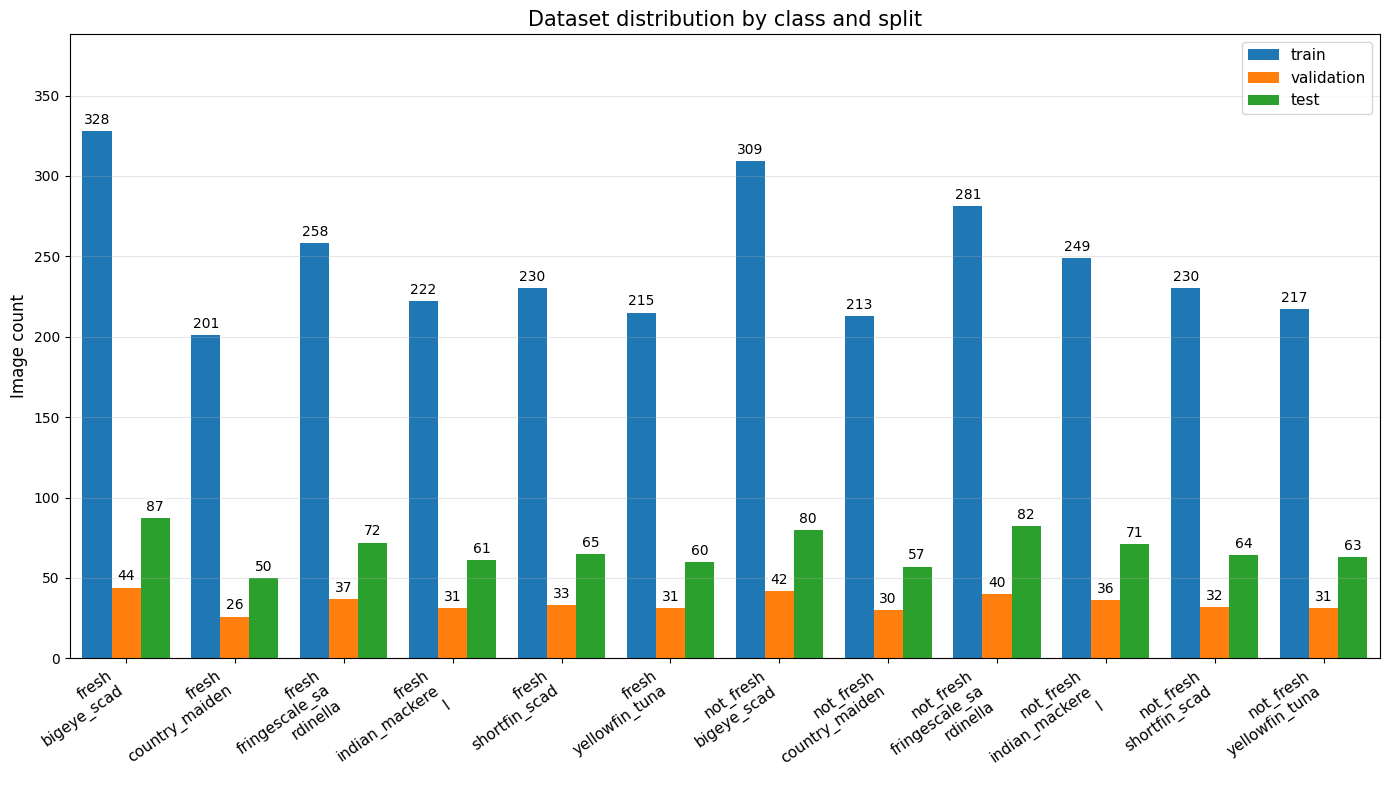

Loaded duplicates from: /kaggle/working/models/duplicates.csv
CSV removed total: 141


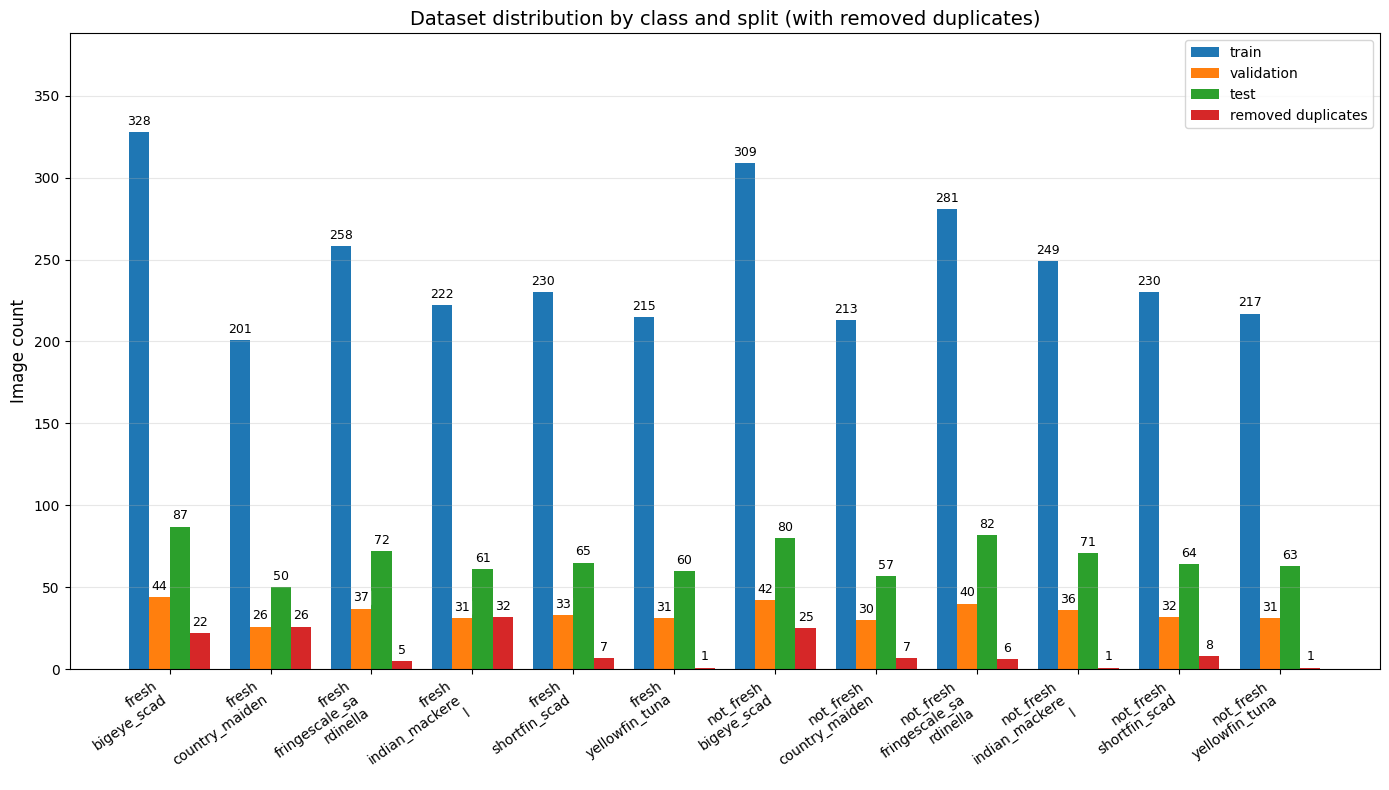

Removed shown in chart (sum): 141
First 6 class/removed: [('fresh__bigeye_scad', 22), ('fresh__country_maiden', 26), ('fresh__fringescale_sardinella', 5), ('fresh__indian_mackerel', 32), ('fresh__shortfin_scad', 7), ('fresh__yellowfin_tuna', 1)]


In [5]:
# === CLEANED DATASET DISTRIBUTION CHARTS (readable labels + exact numbers) ===
# Works with: datasets/{train,validation,testing}/{fresh|not_fresh}/{species}/*.jpg
from pathlib import Path
import os, sys, subprocess, textwrap

# --- CONFIG ---
ROOT   = (MODEL_DIR / "datasets") if "MODEL_DIR" in globals() else Path("datasets")  # base dataset folder
SPLITS = ["train","validation","test"]      # split names present on disk
SAVE_DIR = (MODEL_DIR / "models") if "MODEL_DIR" in globals() else (Path("models") if Path("models").exists() else Path("model/models"))

# --- ensure deps ---
try:
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np
except ModuleNotFoundError:
    Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
    os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
    subprocess.check_call([sys.executable,"-m","pip","install","--no-cache-dir","matplotlib","pandas","numpy"])
    import matplotlib.pyplot as plt
    import pandas as pd
    import numpy as np

# High-DPI for crisp text
plt.gcf().set_dpi(150)

# --- helpers ---
def wrap_class_label(c, width=14):
    """Turn 'fresh__indian_mackerel' -> 'fresh\nindian_mackerel' and wrap long species."""
    parts = c.split("__", 1)
    if len(parts) == 2:
        fresh, species = parts
        species_wrapped = "\n".join(textwrap.wrap(species, width))
        return f"{fresh}\n{species_wrapped}"
    return "\n".join(textwrap.wrap(c, width))

def add_labels_on_bars(bars, values, fontsize=10, pad=3):
    """Add integer labels on top of vertical bars with a white background for contrast."""
    for rect, v in zip(bars, values):
        h = rect.get_height()
        x = rect.get_x() + rect.get_width()/2
        plt.annotate(
            f"{int(v)}",
            (x, h),
            xytext=(0, pad),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8),
        )

def add_labels_on_barh(bars, values, fontsize=10, pad=3):
    """Add integer labels at the end of horizontal bars with a white background for contrast."""
    for rect, v in zip(bars, values):
        w = rect.get_width()
        y = rect.get_y() + rect.get_height()/2
        plt.annotate(
            f"{int(v)}",
            (w, y),
            xytext=(pad, 0),
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.8),
        )

# --- count images per class & split ---
EXTS = {".jpg",".jpeg",".png",".bmp",".webp"}
rows = []
for split in SPLITS:
    base = ROOT / split
    if not base.exists():
        print(f"[skip] missing split: {base}")
        continue
    for freshness in ["fresh","not_fresh"]:
        fdir = base / freshness
        if not fdir.exists():
            continue
        for species_dir in sorted([p for p in fdir.iterdir() if p.is_dir()]):
            n = sum(1 for p in species_dir.rglob("*") if p.suffix.lower() in EXTS)
            rows.append({"class": f"{freshness}__{species_dir.name}", "split": split, "count": n})

df = pd.DataFrame(rows)
if df.empty:
    raise SystemExit("No images found. Check ROOT/SPLITS and your folder structure.")

wide = (
    df.pivot_table(index="class", columns="split", values="count", aggfunc="sum")
      .fillna(0).astype(int)
      .sort_index()
)

SAVE_DIR.mkdir(parents=True, exist_ok=True)
(wide.to_csv(SAVE_DIR/"dataset_counts.csv"))
print("Saved counts ->", (SAVE_DIR/"dataset_counts.csv").resolve())

# --- optional: duplicates removed (if report exists) ---
dup_csv = SAVE_DIR/"duplicates.csv"
dup_counts = None
if dup_csv.exists():
    try:
        ddf = pd.read_csv(dup_csv)
        if "group" in ddf.columns:
            # normalize: convert backslashes, then replace "/" with "__"
            ddf["class_norm"] = (
                ddf["group"].astype(str)
                   .str.replace("\\\\", "/", regex=True)
                   .str.replace("/", "__", regex=False)
            )
            dup_counts = (
                ddf.groupby("class_norm").size()
                   .rename("removed")
                   .to_frame()
            )
            dup_counts.index.name = "class"
            print("Loaded duplicate removals from:", dup_csv.resolve())
            print("Total removed duplicates:", int(dup_counts["removed"].sum()))
        else:
            print("duplicates.csv missing 'group' column; no overlay will be shown.")
    except Exception as e:
        print("Could not read duplicates.csv:", e)
# -------------------------------
# Chart 1: Grouped bars per split
# -------------------------------
classes = wide.index.tolist()
labels_wrapped = [wrap_class_label(c, width=14) for c in classes]
present_splits = [s for s in SPLITS if s in wide.columns]
n_classes = len(classes)
n_splits  = max(1, len(present_splits))
x = np.arange(n_classes)
bar_w = 0.8 / n_splits

fig_w = max(14, n_classes * 1.0)
fig_h = 8
plt.figure(figsize=(fig_w, fig_h))
containers = []

for k, split in enumerate(present_splits):
    xs = x - 0.4 + bar_w/2 + k*bar_w
    bars = plt.bar(xs, wide[split].values, width=bar_w, label=split)
    containers.append((bars, wide[split].values))

# labels on bars
for bars, vals in containers:
    add_labels_on_bars(bars, vals, fontsize=10, pad=3)

plt.xticks(x, labels_wrapped, rotation=35, ha='right', fontsize=11)
plt.ylabel("Image count", fontsize=12)
plt.title("Dataset distribution by class and split", fontsize=15)
plt.legend(fontsize=11)
plt.grid(axis="y", alpha=0.3)
plt.margins(x=0.01)

# y-axis headroom so labels don’t clip
ymax = max(wide[split].max() for split in present_splits) if present_splits else 0
plt.ylim(0, ymax * 1.18 + 1)

plt.tight_layout()
plt.show()

# -------------------------------------------
# Chart 2 (FIXED): grouped bars + a 3rd "removed duplicates" bar
# - picks the correct duplicates.csv
# - unions classes so removed-only classes still appear
# -------------------------------------------
from pathlib import Path
import numpy as np
import pandas as pd
import time

def _pick_dup_csv():
    cands = [
        Path("models/duplicates.csv"),
        Path("model/models/duplicates.csv"),
        Path("model/model/models/duplicates.csv"),
    ]
    cands = [p for p in cands if p.exists()]
    if not cands:
        return None
    # choose the most recently modified
    cands.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return cands[0]

# 1) Rebuild 'wide' if needed (assumes you already have it from Chart 1)
#    wide: index=class ("fresh__species"), columns=[train, validation, testing], values=int

# 2) Load duplicates.csv (most recent in common locations)
dup_csv = _pick_dup_csv()
dup_counts = None
if dup_csv is not None:
    ddf = pd.read_csv(dup_csv)
    def _norm_group(g: str) -> str:
        s = str(g).replace("\\", "/").replace("__", "/")
        parts = [p for p in s.split("/") if p]
        if len(parts) >= 2:
            return f"{parts[-2]}__{parts[-1]}"
        return s.replace("/", "__")
    if "group" in ddf.columns:
        ddf["class_norm"] = ddf["group"].map(_norm_group)
        dup_counts = (
            ddf.groupby("class_norm").size().rename("removed").to_frame()
        )
        dup_counts.index.name = "class"
        print("Loaded duplicates from:", dup_csv.resolve())
        print("CSV removed total:", int(dup_counts["removed"].sum()))
    else:
        print("duplicates.csv missing 'group' column; no removed bar will be shown.")
else:
    print("No duplicates.csv found in expected locations.")

# 3) Build the x-axis class list as a UNION (bars also for classes with zero left)
classes_all = set(wide.index.tolist())
if dup_counts is not None:
    classes_all |= set(dup_counts.index.tolist())
classes = sorted(classes_all)

# reindex 'wide' to include empty classes as zeros
present_splits = [s for s in SPLITS if s in wide.columns]
wide = wide.reindex(classes).fillna(0).astype(int)

# vector aligned with classes for removed
dup_vec = np.zeros(len(classes), dtype=int)
if dup_counts is not None:
    dup_vec = dup_counts.reindex(classes).fillna(0)["removed"].astype(int).values

# 4) Draw grouped bars: train/validation/[…]/removed
x = np.arange(len(classes))
bar_names = present_splits + ["removed"]
n_bars = len(bar_names)
bar_w = 0.8 / n_bars

plt.figure(figsize=(max(14, len(classes) * 1.0), 8))
bar_containers = []

for k, name in enumerate(bar_names):
    xs = x - 0.4 + bar_w/2 + k*bar_w
    if name == "removed":
        vals = dup_vec
        bars = plt.bar(xs, vals, width=bar_w, label="removed duplicates")
    else:
        vals = wide[name].values if name in wide.columns else np.zeros(len(classes), dtype=int)
        label_name = "test" if name == "testing" else name
        bars = plt.bar(xs, vals, width=bar_w, label=label_name)
    bar_containers.append((bars, vals))

def _add_labels(bars, vals, fontsize=9, pad=3):
    for rect, v in zip(bars, vals):
        h = rect.get_height()
        if h <= 0: 
            continue
        cx = rect.get_x() + rect.get_width()/2
        plt.annotate(
            f"{int(v)}",
            (cx, h),
            xytext=(0, pad),
            textcoords="offset points",
            ha="center", va="bottom",
            fontsize=fontsize,
            bbox=dict(boxstyle="round,pad=0.15", facecolor="white", edgecolor="none", alpha=0.85),
        )

# annotate every bar
for bars, vals in bar_containers:
    _add_labels(bars, vals)

# x labels
def wrap_label(c, width=14):
    a = c.split("__", 1)
    if len(a) == 2:
        return a[0] + "\n" + "\n".join(pd.Series([a[1]]).str.wrap(width).iloc[0].split("\n"))
    return c
labels_wrapped = [wrap_label(c, 14) for c in classes]

plt.xticks(x, labels_wrapped, rotation=35, ha='right', fontsize=10)
plt.ylabel("Image count", fontsize=12)
plt.title("Dataset distribution by class and split (with removed duplicates)", fontsize=14)
plt.grid(axis="y", alpha=0.3)
plt.legend(fontsize=10)

# headroom
ymax = 0
for _, vals in bar_containers:
    if len(vals):
        ymax = max(ymax, int(np.max(vals)))
plt.ylim(0, ymax * 1.18 + 1)

plt.tight_layout()
plt.show()

# 5) Sanity checks
print("Removed shown in chart (sum):", int(dup_vec.sum()))

print("First 6 class/removed:", list(zip(classes[:6], dup_vec[:6])))



## 6) (Datasets Splitting) Flatten dataset to ImageFolder layout

In [6]:
# 3) Flatten dataset to ImageFolder (freshness__species, Kaggle + local)
from pathlib import Path
import shutil, json

# We assume the split cell already created:
#   MODEL_DIR/datasets/{train,validation,test}/{fresh,not_fresh}/{species}/*.jpg
SRC = MODEL_DIR / "datasets"          # source: split folders
DST = MODEL_DIR / "pytorch_cls"
#DST = MODEL_DIR / "pytorch_imagenet"  # dest: ImageFolder layout train/val/test
DST.mkdir(parents=True, exist_ok=True)

print("Flatten SRC:", SRC.resolve())
print("Flatten DST:", DST.resolve())

if not (SRC / "train").exists():
    raise SystemExit(
        "Expected 'datasets/train' under MODEL_DIR. "
        "Run the auto-split / split_multitask step first."
    )

ALLOWED_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

def flatten_split(split_name: str, out_name: str):
    src = SRC / split_name
    out = DST / out_name

    if not src.exists():
        print(f"[skip] {src} not found")
        return False

    # wipe existing split
    if out.exists():
        shutil.rmtree(out)
    out.mkdir(parents=True, exist_ok=True)

    copied = 0
    for freshness in ["fresh", "not_fresh"]:
        base = src / freshness
        if not base.exists():
            print(f"[warn] missing {base}")
            continue

        for sp_dir in base.iterdir():
            if not sp_dir.is_dir():
                continue

            # <-- DOUBLE UNDERSCORE BETWEEN FRESHNESS & SPECIES
            cls_name = f"{freshness}__{sp_dir.name}"
            out_cls = out / cls_name
            out_cls.mkdir(parents=True, exist_ok=True)

            for img in sp_dir.rglob("*"):
                if img.is_file() and img.suffix.lower() in ALLOWED_EXT:
                    os.symlink(img, out_cls / img.name)
                    copied += 1

    print(f"[done] {split_name} -> {out}  (copied {copied} files)")
    return copied > 0

ok_train = flatten_split("train", "train")
ok_val   = flatten_split("validation", "val")
ok_test  = flatten_split("test", "test")

if not ok_train:
    raise SystemExit(
        "No training images were copied. Check your source layout: "
        "datasets/train/{fresh,not_fresh}/{species}/*.jpg"
    )

# ---- Build structured class list (Freshness + Species) ----
train_dir = DST / "train"
all_classes = sorted([p.name for p in train_dir.iterdir() if p.is_dir()])
NUM_CLASSES = len(all_classes)

print("\nFound classes:")
for i, c in enumerate(all_classes):
    print(f"  {i:2d} -> {c}")
print("Total classes:", NUM_CLASSES)

# Extract species from folder names like 'fresh__indian_mackerel'
species_classes = sorted(
    {c.split("__", 1)[1] for c in all_classes if "__" in c}
)

# Old convention: human-readable freshness labels
freshness_classes = ["Fresh", "Not Fresh"]

# Make sure models directory exists
(MODEL_DIR / "models").mkdir(parents=True, exist_ok=True)

# Structured JSON in the same style as your old notebook
structured_classes = {
    "freshness_classes": freshness_classes,
    "species_classes": species_classes,
}

classes_path = MODEL_DIR / "models" / "classes.json"
classes_path.write_text(json.dumps(structured_classes, indent=2))

# Optional: also save the flat list (full label names)
(MODEL_DIR / "models" / "classes_flat.json").write_text(
    json.dumps(all_classes, indent=2)
)

print(f"\n✅ Wrote structured classes.json to {classes_path.resolve()}")
print("Freshness labels:", freshness_classes)
print("Species labels:", species_classes)


Flatten SRC: /kaggle/working/datasets
Flatten DST: /kaggle/working/pytorch_cls
[done] train -> pytorch_cls/train  (copied 2953 files)
[done] validation -> pytorch_cls/val  (copied 413 files)
[done] test -> pytorch_cls/test  (copied 812 files)

Found classes:
   0 -> fresh__bigeye_scad
   1 -> fresh__country_maiden
   2 -> fresh__fringescale_sardinella
   3 -> fresh__indian_mackerel
   4 -> fresh__shortfin_scad
   5 -> fresh__yellowfin_tuna
   6 -> not_fresh__bigeye_scad
   7 -> not_fresh__country_maiden
   8 -> not_fresh__fringescale_sardinella
   9 -> not_fresh__indian_mackerel
  10 -> not_fresh__shortfin_scad
  11 -> not_fresh__yellowfin_tuna
Total classes: 12

✅ Wrote structured classes.json to /kaggle/working/models/classes.json
Freshness labels: ['Fresh', 'Not Fresh']
Species labels: ['bigeye_scad', 'country_maiden', 'fringescale_sardinella', 'indian_mackerel', 'shortfin_scad', 'yellowfin_tuna']


## 6.1 BUILD CLS-STYKE CROP USING YOLO

In [7]:
from pathlib import Path

DST_ORIG = Path("/kaggle/working/datasets")   # ✅ this is your source dataset
SRC = DST_ORIG                                # ✅ read from the source dataset
DST_CLS = Path("/kaggle/working/pytorch_cls")  # ✅ write the new cropped dataset here

print("SRC =", SRC)
print("DST_CLS =", DST_CLS)

SRC = /kaggle/working/datasets
DST_CLS = /kaggle/working/pytorch_cls


# NOT NEEDED DONT RUN FROM HERE

In [ ]:
!rm -rf /kaggle/working/pytorch_cls_flat

In [ ]:
!find /kaggle/working -maxdepth 2 -type d -name "train"

## TO HERE

## 6.2) BUILD CLS-Style crop using yolo

In [10]:
from ultralytics import YOLO
from pathlib import Path
from PIL import Image, ImageOps
import shutil
import numpy as np
import cv2

# -------------------------
# 1) Paths (Kaggle)
# -------------------------
SRC = Path("/kaggle/working/datasets")                  # input
DST_CLS = Path("/kaggle/working/pytorch_cls")    # ✅ output like screenshot

# reset output (optional but recommended)
if DST_CLS.exists():
    shutil.rmtree(DST_CLS)
DST_CLS.mkdir(parents=True, exist_ok=True)

# -------------------------
# 2) YOLO weights (.pt)
# -------------------------
YOLO_PT = Path("/kaggle/input/yolo-weights/other/default/1/yolov8s-oiv7.pt")
assert YOLO_PT.exists(), f"YOLO weights not found: {YOLO_PT}"

YOLO_LOCAL = Path("/kaggle/working/yolov8s-oiv7.pt")
if not YOLO_LOCAL.exists():
    shutil.copy2(YOLO_PT, YOLO_LOCAL)

yolo = YOLO(str(YOLO_LOCAL))

# -------------------------
# 3) Inference params
# -------------------------
IMG_SIZE = 768
CONF     = 0.05
MAX_DET  = 50
FISH_CLS = 192

# -------------------------
# 4) Helpers
# -------------------------
def pad_rect_xyxy(x1, y1, x2, y2, W, H, padx=0.08, pady=0.60):
    bw, bh = (x2 - x1), (y2 - y1)
    cx, cy = (x1 + x2) / 2.0, (y1 + y2) / 2.0
    bw2 = bw * (1 + 2 * padx)
    bh2 = bh * (1 + 2 * pady)
    nx1 = max(0, int(cx - bw2 / 2)); ny1 = max(0, int(cy - bh2 / 2))
    nx2 = min(W, int(cx + bw2 / 2)); ny2 = min(H, int(cy + bh2 / 2))
    if nx2 <= nx1 or ny2 <= ny1:
        return 0, 0, W, H
    return nx1, ny1, nx2, ny2

def to_cls224(im: Image.Image, fill=(114, 114, 114)):
    w, h = im.size
    s = max(w, h)
    pad_left = (s - w) // 2
    pad_top = (s - h) // 2
    pad_right = s - w - pad_left
    pad_bottom = s - h - pad_top
    im = ImageOps.expand(im, border=(pad_left, pad_top, pad_right, pad_bottom), fill=fill)
    return im.resize((640, 640), resample=Image.BICUBIC)

def best_fish_box_largest(result, fish_cls=FISH_CLS, min_conf=0.05, min_area_frac=0.05):
    if result.boxes is None or len(result.boxes) == 0:
        return None
    boxes = result.boxes.xyxy.cpu().numpy()
    cls   = result.boxes.cls.cpu().numpy().astype(int)
    conf  = result.boxes.conf.cpu().numpy()

    mask = (cls == fish_cls) & (conf >= min_conf)
    if not mask.any():
        return None

    boxes = boxes[mask]
    H, W = result.orig_shape
    areas = (boxes[:, 2] - boxes[:, 0]) * (boxes[:, 3] - boxes[:, 1])
    area_frac = areas / (W * H + 1e-9)

    keep = area_frac >= min_area_frac
    if not keep.any():
        return None

    boxes = boxes[keep]
    areas = areas[keep]
    return boxes[int(np.argmax(areas))]

# -------------------------
# 5) Split mapping (THIS fixes your issue)
# -------------------------
SPLIT_MAP = {
    "train":      ["train"],
    "validation": ["validation", "val"],   # ✅ accept either folder name
    "test":       ["test"],
}

def find_existing_split(split_key: str) -> Path | None:
    for name in SPLIT_MAP[split_key]:
        p = SRC / name
        if p.exists():
            return p
    return None

def build_split(split_key: str):
    src_split = find_existing_split(split_key)
    if src_split is None:
        print(f"Skip missing split: {split_key} (looked for {SPLIT_MAP[split_key]})")
        return

    out_split = DST_CLS / split_key
    out_split.mkdir(parents=True, exist_ok=True)

    count = 0

    for freshness_dir in src_split.iterdir():
        if not freshness_dir.is_dir():
            continue

        for species_dir in freshness_dir.iterdir():
            if not species_dir.is_dir():
                continue

            out_dir = out_split / freshness_dir.name / species_dir.name
            out_dir.mkdir(parents=True, exist_ok=True)

            imgs = [p for p in species_dir.rglob("*") if p.suffix.lower() in [".jpg", ".jpeg", ".png"]]

            for p in imgs:
                im_bgr = cv2.imread(str(p))
                if im_bgr is None:
                    continue
                H, W = im_bgr.shape[:2]

                r = yolo.predict(
                    source=im_bgr, imgsz=IMG_SIZE, conf=CONF, max_det=MAX_DET, verbose=False
                )[0]

                b = best_fish_box_largest(r)

                if b is None:
                    im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
                    out = to_cls224(Image.fromarray(im_rgb))
                else:
                    x1, y1, x2, y2 = map(float, b)
                    x1, y1, x2, y2 = pad_rect_xyxy(x1, y1, x2, y2, W, H)
                    crop_bgr = im_bgr[int(y1):int(y2), int(x1):int(x2)]
                    if crop_bgr.size == 0:
                        im_rgb = cv2.cvtColor(im_bgr, cv2.COLOR_BGR2RGB)
                        out = to_cls224(Image.fromarray(im_rgb))
                    else:
                        crop_rgb = cv2.cvtColor(crop_bgr, cv2.COLOR_BGR2RGB)
                        out = to_cls224(Image.fromarray(crop_rgb))

                out.save(out_dir / (p.stem + "__cls.jpg"), quality=95)
                count += 1

    print(f"Done: {split_key} | source={src_split.name} | images_saved={count}")

# Run
for split_key in ["train", "validation", "test"]:
    build_split(split_key)

print("✅ CLS dataset created at:", DST_CLS)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Done: train | source=train | images_saved=2953
Done: validation | source=validation | images_saved=413
Done: test | source=test | images_saved=812
✅ CLS dataset created at: /kaggle/working/pytorch_cls


In [ ]:
!rm -rf /kaggle/working/pytorch_cls
# remove 

## DOWNLOAD ZIP FILE THEN CHECK

In [ ]:
!cd /kaggle/working && zip -r pytorch_cls.zip pytorch_cls
# create zip file

## CONFIRMATION ONLY

In [11]:
names = yolo.model.names
fish_ids = [k for k,v in names.items() if v.strip().lower() == "fish"]
print("fish_ids:", fish_ids)
FISH_CLS = fish_ids[0] if fish_ids else 192
print("Using FISH_CLS:", FISH_CLS, names.get(FISH_CLS))


fish_ids: [192]
Using FISH_CLS: 192 Fish


## 7) DONT RUN multi-fish inference crops**

In [ ]:
from PIL import Image, ImageOps
import random, math

class PadToSquare:
    def __init__(self, fill=(114,114,114)):
        self.fill = fill
    def __call__(self, img):
        w, h = img.size
        if w == h: return img
        m = max(w, h)
        pad_left = (m - w) // 2
        pad_top  = (m - h) // 2
        pad_right = m - w - pad_left
        pad_bottom = m - h - pad_top
        return ImageOps.expand(img, border=(pad_left, pad_top, pad_right, pad_bottom), fill=self.fill)


class RandomDetectorCrop:
    """
    Simulate YOLO crops: rectangular crop around center with jitter.
    Works well because your dataset fish are centered.
    """
    def __init__(self, scale=(0.55, 1.00), ratio=(0.35, 2.80), center_jitter=0.12):
        self.scale = scale
        self.ratio = ratio
        self.center_jitter = center_jitter

    def __call__(self, img: Image.Image):
        w, h = img.size
        area = w * h

        s = random.uniform(*self.scale)
        r = random.uniform(*self.ratio)
        crop_w = int(round(math.sqrt(s * area * r)))
        crop_h = int(round(math.sqrt(s * area / r)))

        crop_w = max(10, min(crop_w, w))
        crop_h = max(10, min(crop_h, h))

        cx = w // 2 + int((random.uniform(-1, 1) * self.center_jitter) * w)
        cy = h // 2 + int((random.uniform(-1, 1) * self.center_jitter) * h)

        left = max(0, min(w - crop_w, cx - crop_w // 2))
        top  = max(0, min(h - crop_h, cy - crop_h // 2))

        return img.crop((left, top, left + crop_w, top + crop_h))


## 8) (Augmentation) Dataloaders & transforms with downsampling the training set

In [12]:
from pathlib import Path
from collections import Counter, defaultdict
import random
import torch
from torch.utils.data import DataLoader, Subset, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from PIL import Image

# ---- defaults ----
INPUT_SIZE    = int(globals().get('INPUT_SIZE', 224))
BATCH         = int(globals().get('BATCH', 32))
NUM_WORKERS   = int(globals().get('NUM_WORKERS', 4))
PIN_MEMORY    = bool(globals().get('PIN_MEMORY', True))
SEED          = int(globals().get('SEED', 123))
RESIZE_FACTOR = 1.15
TARGET_PER_CLASS = 5000

random.seed(SEED)
torch.manual_seed(SEED)

# ---- locate NESTED dataset root ----
if 'MODEL_DIR' in globals() and (MODEL_DIR / 'pytorch_cls' / 'train').exists():
    DST = MODEL_DIR / 'pytorch_cls'
elif Path('/kaggle/working/pytorch_cls/train').exists():
    DST = Path('/kaggle/working/pytorch_cls')
elif Path('pytorch_cls/train').exists():
    DST = Path('pytorch_cls')
else:
    raise SystemExit("Couldn't find pytorch_cls/train")

# resolve validation folder name
if (DST / "validation").exists():
    VAL_DIR = DST / "validation"
elif (DST / "val").exists():
    VAL_DIR = DST / "val"
else:
    raise SystemExit(f"Missing validation split at {DST/'validation'} (or {DST/'val'})")

TRAIN_DIR = DST / "train"

IMG_EXTS = {".jpg", ".jpeg", ".png"}

class NestedFreshSpeciesDataset(Dataset):
    """
    Expects:
      split/
        fresh/species/*.jpg
        not_fresh/species/*.jpg

    Produces classes like: fresh__species, not_fresh__species
    """
    def __init__(self, split_dir: Path, transform=None, class_to_idx=None):
        self.split_dir = Path(split_dir)
        self.transform = transform

        samples = []
        discovered = set()

        for freshness_dir in sorted([p for p in self.split_dir.iterdir() if p.is_dir()]):
            freshness = freshness_dir.name  # fresh / not_fresh

            for species_dir in sorted([p for p in freshness_dir.iterdir() if p.is_dir()]):
                species = species_dir.name
                cls_name = f"{freshness}__{species}"
                discovered.add(cls_name)

                for img_path in species_dir.rglob("*"):
                    if img_path.is_file() and img_path.suffix.lower() in IMG_EXTS:
                        samples.append((img_path, cls_name))

        # build mapping from TRAIN set (recommended), or from this split if none provided
        if class_to_idx is None:
            classes = sorted(discovered)
            class_to_idx = {c: i for i, c in enumerate(classes)}
        else:
            # keep class order identical to train
            classes = sorted(class_to_idx.keys(), key=lambda k: class_to_idx[k])

        # convert to (path, idx) and filter unknown classes (shouldn’t happen if val matches train)
        self.samples = []
        for p, cls_name in samples:
            if cls_name in class_to_idx:
                self.samples.append((p, class_to_idx[cls_name]))

        self.targets = [y for _, y in self.samples]
        self.class_to_idx = class_to_idx
        self.classes = classes

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        path, y = self.samples[i]
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, y

# ---- transforms (add resize/crop so training matches inference size) ----
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    # 1. Geometric: Handles fish at any angle or slightly off-center
    transforms.RandomResizedCrop(INPUT_SIZE, scale=(0.8, 1.0)), 
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5), # Fish can be oriented any way
    transforms.RandomRotation(degrees=30), 

    # 2. Color: Handles different lighting in your app/mobile camera
    transforms.RandomApply([transforms.ColorJitter(
        brightness=0.4,  # Allow much darker/brighter images
        contrast=0.4,    # Allow washed out or high-contrast looks
        saturation=0.4,  # specific for Gills (color intensity)
        hue=0.1          # CRITICAL: Handles "Yellow Market Lights" shifting colors
    )], p=0.80),
    transforms.RandomAutocontrast(p=0.25),
    
    # 3. Focus on Texture: Helps with freshness detection
    transforms.RandomAdjustSharpness(sharpness_factor=2.0, p=0.25), 

    transforms.ToTensor(),

    transforms.RandomErasing(p=0.2, scale=(0.02, 0.2), ratio=(0.3, 3.3), value='random'),
    
    transforms.Normalize(mean, std),
])

val_tfms = transforms.Compose([
    #transforms.Resize(int(INPUT_SIZE * RESIZE_FACTOR), interpolation=InterpolationMode.BILINEAR),
    #transforms.CenterCrop(INPUT_SIZE),
    transforms.Resize((INPUT_SIZE, INPUT_SIZE), interpolation=InterpolationMode.BILINEAR),
    transforms.ToTensor(),
    transforms.Normalize(mean, std),
])

# ---- build TRAIN first (defines class_to_idx) ----
train_base = NestedFreshSpeciesDataset(TRAIN_DIR, transform=train_tfms)
CLASSES = train_base.classes
val_ds  = NestedFreshSpeciesDataset(VAL_DIR, transform=val_tfms, class_to_idx=train_base.class_to_idx)

# === PRINT ALL CLASSES ===
print("\n=== CLASS INDEX → NAME ===")
for idx, cls in enumerate(CLASSES):
    print(f"{idx:2d} -> {cls}")
print("Num classes:", len(CLASSES), "\n")

print("=== CLASS DETAILS (parsed) ===")
for idx, cls in enumerate(CLASSES):
    freshness, species = cls.split("__", 1)
    print(f"{idx:2d} | freshness: {freshness:10s} | species: {species}")
print()

# ---------- helpers ----------
def labels_from_dataset(ds):
    if hasattr(ds, "targets"):
        return list(ds.targets)
    elif hasattr(ds, "samples"):
        return [y for _, y in ds.samples]
    raise AttributeError("Expected dataset to have .targets or .samples")

def count_by_class(ds, indices=None):
    if indices is None:
        labels = labels_from_dataset(ds)
    else:
        labels = [ds.targets[i] for i in indices] if hasattr(ds, "targets") else [ds.samples[i][1] for i in indices]
    return Counter(labels)

# ---- show counts BEFORE ----
before_counts = count_by_class(train_base)
print("Before (per class):")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:35s} -> {before_counts.get(i, 0)}")
print(f"Total before: {sum(before_counts.values())}\n")

# ---- build balanced_indices (cap per class) ----
idxs_by_class = defaultdict(list)
for idx, (_, y) in enumerate(train_base.samples):
    idxs_by_class[y].append(idx)

cap = min(len(v) for v in idxs_by_class.values()) if TARGET_PER_CLASS is None else TARGET_PER_CLASS

balanced_indices = []
for c, idxs in idxs_by_class.items():
    k = min(len(idxs), cap)
    balanced_indices.extend(idxs if k == len(idxs) else random.sample(idxs, k))

train_ds = Subset(train_base, balanced_indices)

# ---- show counts AFTER ----
after_counts = count_by_class(train_base, balanced_indices)
print("After (per class):")
for i, cls in enumerate(CLASSES):
    print(f"  {cls:35s} -> {after_counts.get(i, 0)}")
print(f"Total after: {sum(after_counts.values())}\n")

# ---- dataloaders ----
loaders = {
    'train': DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False),
    'val': DataLoader(val_ds, batch_size=BATCH, shuffle=False,
                      num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=False),
}

print("Using dataset root:", DST.resolve())
print("Train classes:", len(CLASSES), " Train batches:", len(loaders['train']), " Val batches:", len(loaders['val']))
print("INPUT_SIZE:", INPUT_SIZE, " BATCH:", BATCH, " NUM_WORKERS:", NUM_WORKERS, " PIN_MEMORY:", PIN_MEMORY)



=== CLASS INDEX → NAME ===
 0 -> fresh__bigeye_scad
 1 -> fresh__country_maiden
 2 -> fresh__fringescale_sardinella
 3 -> fresh__indian_mackerel
 4 -> fresh__shortfin_scad
 5 -> fresh__yellowfin_tuna
 6 -> not_fresh__bigeye_scad
 7 -> not_fresh__country_maiden
 8 -> not_fresh__fringescale_sardinella
 9 -> not_fresh__indian_mackerel
10 -> not_fresh__shortfin_scad
11 -> not_fresh__yellowfin_tuna
Num classes: 12 

=== CLASS DETAILS (parsed) ===
 0 | freshness: fresh      | species: bigeye_scad
 1 | freshness: fresh      | species: country_maiden
 2 | freshness: fresh      | species: fringescale_sardinella
 3 | freshness: fresh      | species: indian_mackerel
 4 | freshness: fresh      | species: shortfin_scad
 5 | freshness: fresh      | species: yellowfin_tuna
 6 | freshness: not_fresh  | species: bigeye_scad
 7 | freshness: not_fresh  | species: country_maiden
 8 | freshness: not_fresh  | species: fringescale_sardinella
 9 | freshness: not_fresh  | species: indian_mackerel
10 | freshne

In [13]:
from pathlib import Path

print("DST:", DST.resolve())
print("\nTop-level train dirs:")
for p in (DST/'train').iterdir():
    if p.is_dir():
        print("  ", p.name)

print("\nExample subdirs:")
for p in (DST/'train').iterdir():
    if p.is_dir():
        children = [c.name for c in p.iterdir() if c.is_dir()]
        print(f"  {p.name} -> {children[:5]}")

DST: /kaggle/working/pytorch_cls

Top-level train dirs:
   fresh
   not_fresh

Example subdirs:
  fresh -> ['shortfin_scad', 'indian_mackerel', 'fringescale_sardinella', 'yellowfin_tuna', 'country_maiden']
  not_fresh -> ['shortfin_scad', 'indian_mackerel', 'fringescale_sardinella', 'yellowfin_tuna', 'country_maiden']


## 7.1 Weighted CrossEntropyloss for imbalance datasets

In [14]:
from collections import Counter
import numpy as np
import torch
import torch.nn as nn

# get labels from your train_ds
if hasattr(train_ds, "targets"):
    labels = np.array(train_ds.targets)
else:
    labels = np.array([train_ds.dataset.targets[i] for i in train_ds.indices])

counts = Counter(labels)
n_samples = len(labels)
n_classes = len(CLASSES)

# balanced class weights
raw = np.array([n_samples / (n_classes * counts[i]) for i in range(n_classes)], dtype=np.float32)
raw = raw / raw.mean()  # normalize so mean ~1

weights = torch.tensor(raw, dtype=torch.float32)

# ⬇️ ADD THIS PRINT HERE
print("\n=== Class Counts & Weights ===")
for i, cls_name in enumerate(CLASSES):
    print(f"{i:2d}  {cls_name:30s}  count={counts[i]:3d}  weight={raw[i]:.3f}")
print()

# create final loss
device = 'cuda' if torch.cuda.is_available() else 'cpu'
criterion = nn.CrossEntropyLoss(weight=weights.to(device))



=== Class Counts & Weights ===
 0  fresh__bigeye_scad              count=328  weight=0.734
 1  fresh__country_maiden           count=201  weight=1.197
 2  fresh__fringescale_sardinella   count=258  weight=0.933
 3  fresh__indian_mackerel          count=222  weight=1.084
 4  fresh__shortfin_scad            count=230  weight=1.046
 5  fresh__yellowfin_tuna           count=215  weight=1.119
 6  not_fresh__bigeye_scad          count=309  weight=0.779
 7  not_fresh__country_maiden       count=213  weight=1.130
 8  not_fresh__fringescale_sardinella  count=281  weight=0.856
 9  not_fresh__indian_mackerel      count=249  weight=0.966
10  not_fresh__shortfin_scad        count=230  weight=1.046
11  not_fresh__yellowfin_tuna       count=217  weight=1.109



## 8) Build model from the selected GitHub repo

In [15]:
# === BUILD ResNet50 (official torchvision) ===
import torch, torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Determine class count from globals or datasets (unchanged)
if 'NUM_CLASSES' in globals():
    NUM_CLASSES = int(NUM_CLASSES)
elif 'CLASSES' in globals():
    NUM_CLASSES = len(CLASSES)
elif 'data' in globals() and 'train' in data:
    NUM_CLASSES = len(data['train'].classes)
else:
    raise SystemExit("Can't determine NUM_CLASSES. Run dataloaders first so CLASSES/data exist.")

# ---- config flags (keep behavior similar to your MobileNet cell) ----
# If you already had a USE_IMAGENET_WEIGHTS flag before, this will respect it.
USE_IMAGENET_WEIGHTS = globals().get("USE_IMAGENET_WEIGHTS", True)

# Choose pretrained weights or random init (same logic, just for ResNet50)
if USE_IMAGENET_WEIGHTS:
    weights = ResNet50_Weights.IMAGENET1K_V1
    print("Using ResNet50 ImageNet-1K pretrained weights")
else:
    weights = None
    print("Using ResNet50 with random init (no pretrained weights)")

# ---- build model and replace classifier head only ----
base = resnet50(weights=weights)

# ResNet50 uses .fc as the final classifier layer
in_feats = base.fc.in_features

# MODIFIED: Add a Dropout layer before the Linear layer to reduce overfitting
base.fc = nn.Sequential(
    nn.Dropout(p=0.5), # Randomly zeroes 50% of connections to prevent memorization
    nn.Linear(in_feats, NUM_CLASSES, bias=True)
)

model = base.to(device)

print(f"Built official torchvision ResNet50 -> num_classes={NUM_CLASSES}")
with torch.no_grad():
    _ = model(torch.randn(1, 3, 224, 224, device=device))
print("Sanity forward OK on", device)


Using ResNet50 ImageNet-1K pretrained weights


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 188MB/s] 


Built official torchvision ResNet50 -> num_classes=12
Sanity forward OK on cuda


In [ ]:
# Install tqdm from inside the notebook (Windows-safe temp paths)
import sys, subprocess, os
from pathlib import Path
Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-cache-dir", "tqdm"])

from tqdm.auto import tqdm
print("tqdm ready ✅")


## 8.1) MODEL CONFIRMATION

In [16]:
# === MODEL SOURCE CONFIRMATION — ResNet50 (torchvision, robust) ===
import torch
from torchvision import models
from torchvision.transforms import Normalize

print("PyTorch version:", torch.__version__)
print("Model source:", models.resnet.__name__)
print("Model name:", "ResNet50")

# Load temporary pretrained model for metadata + sanity
weights = models.ResNet50_Weights.IMAGENET1K_V1
m_pretrained = models.resnet50(weights=weights)

# --- helper to extract mean/std from meta or transforms ---
def extract_mean_std(weights_enum):
    mean = std = None
    # 1) Try metadata
    try:
        meta = weights_enum.meta
        mean = meta.get("mean", None)
        std  = meta.get("std", None)
        if mean is not None and std is not None:
            return list(mean), list(std), "weights.meta"
    except Exception:
        pass

    # 2) Try walking transforms
    try:
        tfm = weights_enum.transforms()
        stack = [tfm]
        visited = set()
        while stack:
            t = stack.pop()
            if id(t) in visited:
                continue
            visited.add(id(t))
            if isinstance(t, Normalize):
                return list(t.mean), list(t.std), "weights.transforms()"
            # torchvision Compose-style containers
            if hasattr(t, "transforms") and isinstance(t.transforms, (list, tuple)):
                stack.extend(t.transforms)
            # Sometimes stored under `.transform` (>=0.15)
            for attr in ("transform", "aug"):
                if hasattr(t, attr):
                    stack.append(getattr(t, attr))
    except Exception:
        pass

    # 3) Fallback to ImageNet defaults
    return [0.485, 0.456, 0.406], [0.229, 0.224, 0.225], "fallback(defaults)"

mean, std, src = extract_mean_std(weights)

# Safe getter for metadata fields
def safe(key, default="N/A"):
    try:
        v = weights.meta.get(key, None)
        return v if v is not None else default
    except Exception:
        return default

print("\nPretrained configuration metadata:")
print("• Weights enum:", weights)
print("• Weights URL:", safe("url", "None"))
print("• Categories:", len(safe("categories", [])), "(ImageNet classes)")
print("• Input size expected:", safe("input_size", "(3, 224, 224)"))
print("• Mean:", mean, f"(source: {src})")
print("• Std:", std,   f"(source: {src})")
print("• Model architecture:", m_pretrained.__class__.__name__)
print("• Parameter count:", f"{sum(p.numel() for p in m_pretrained.parameters()):,}")

# --- Compare with YOUR fine-tuned ResNet50 (if built already as 'model') ---
if 'model' in globals():
    p1 = sum(p.numel() for p in m_pretrained.parameters())
    p2 = sum(p.numel() for p in model.parameters())
    print(f"\nParameter difference (pretrained vs fine-tuned): {abs(p1 - p2):,}")

    # ResNet50 uses .fc as final layer
    out_features = getattr(model.fc, "out_features", "?")
    print(f"✅ Using pretrained ResNet50 backbone replaced to output {out_features} classes.")
else:
    print("\n⚠️ Fine-tuned model not yet loaded — showing pretrained metadata only.")


PyTorch version: 2.6.0+cu124
Model source: torchvision.models.resnet
Model name: ResNet50

Pretrained configuration metadata:
• Weights enum: ResNet50_Weights.IMAGENET1K_V1
• Weights URL: None
• Categories: 1000 (ImageNet classes)
• Input size expected: (3, 224, 224)
• Mean: [0.485, 0.456, 0.406] (source: fallback(defaults))
• Std: [0.229, 0.224, 0.225] (source: fallback(defaults))
• Model architecture: ResNet
• Parameter count: 25,557,032

Parameter difference (pretrained vs fine-tuned): 2,024,412
✅ Using pretrained ResNet50 backbone replaced to output ? classes.


**RUN BEFORE TRAINING**

In [ ]:
import torch

CKPT_LOAD_PATH = "/kaggle/input/bestpth/resnet50_torchvision_best.pth"

checkpoint = torch.load(CKPT_LOAD_PATH, map_location='cuda')

model.load_state_dict(checkpoint['model'])
start_epoch = checkpoint.get('epoch', 0)
best_acc = checkpoint.get('val_acc', 0)

print("Loaded checkpoint:")
print("  Epoch:", start_epoch)
print("  Best val acc:", best_acc)


In [ ]:
import torch
import subprocess
import os

print("===== GPU / CUDA CHECK =====")

# 1. Check CUDA availability
print("CUDA Available:", torch.cuda.is_available())

# 2. Device PyTorch will use
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch device:", device)

# 3. Detailed GPU name
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
    print("CUDA Capability:", torch.cuda.get_device_capability(0))
else:
    print("No GPU detected.")

# 4. Memory check
if torch.cuda.is_available():
    print("Allocated memory:", torch.cuda.memory_allocated() / 1024**2, "MB")
    print("Cached memory:", torch.cuda.memory_reserved() / 1024**2, "MB")

# 5. Check if nvidia-smi is available
print("\n===== NVIDIA-SMI OUTPUT =====")
try:
    smi_output = subprocess.check_output("nvidia-smi", shell=True).decode()
    print(smi_output)
except Exception as e:
    print("nvidia-smi not available:", e)

print("=================================")


## 9) Train with SGD + Cosine LR + AMP

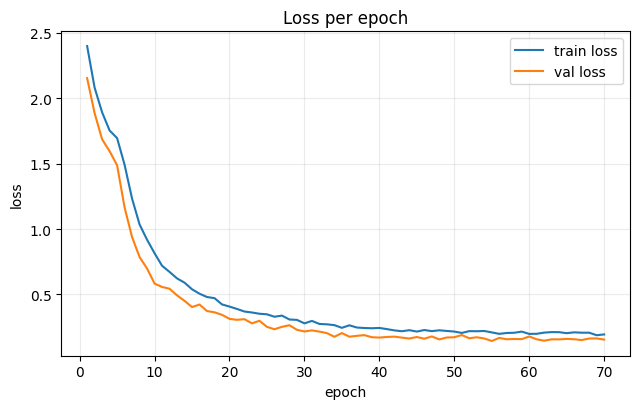

Epoch 70/70 train loss 0.1951 acc 0.9374 | val loss 0.1556 acc 0.9467 (best 0.9540) LR 0.000001
Best val acc: 0.9539951573849879 
Saved best checkpoint -> models/resnet50_torchvision_best.pth


In [17]:
# === TRAIN + LIVE LOSS PLOT (per-epoch) — ResNet50, staged fine-tune (head then full) ===

import torch, torch.nn as nn
from torch.optim import SGD
from torch.optim.lr_scheduler import CosineAnnealingLR
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from IPython.display import clear_output, display
from pathlib import Path

# ---------------------------------------------------------
# Device
# ---------------------------------------------------------
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

# ---------------------------------------------------------
# Hyperparams
# ---------------------------------------------------------
EPOCHS       = int(globals().get('EPOCHS', 70))
LR           = float(globals().get('LR', 0.001))
WEIGHT_DECAY = float(globals().get('WEIGHT_DECAY', 1e-3))
WARMUP_EPOCHS = int(globals().get('WARMUP_EPOCHS', 5))  # head-only epochs

# ---------------------------------------------------------
# Paths
# ---------------------------------------------------------
MODEL_DIR_LOCAL = globals().get('MODEL_DIR', Path('model') if Path('model').exists() else Path('.'))
OUT_DIR = MODEL_DIR_LOCAL / 'models'
OUT_DIR.mkdir(parents=True, exist_ok=True)
ckpt_path = OUT_DIR / "resnet50_torchvision_best.pth"

# ---------------------------------------------------------
# Model, loaders, loss
# ---------------------------------------------------------
model     = globals().get('model', model).to(device)
loaders   = globals().get('loaders', loaders)
criterion = globals().get('criterion', nn.CrossEntropyLoss())

def get_head_params(m):
    """
    Returns (head_params, head_name) for common torchvision models.
    Works for ResNet (fc) and MobileNet/EfficientNet (classifier).
    """
    if hasattr(m, "fc") and isinstance(m.fc, nn.Module):
        return list(m.fc.parameters()), "fc"
    if hasattr(m, "classifier") and isinstance(m.classifier, nn.Module):
        return list(m.classifier.parameters()), "classifier"
    raise RuntimeError("Could not find model head (fc/classifier).")

# -------------------------
# STAGE 1: Freeze backbone
# -------------------------
for p in model.parameters():
    p.requires_grad = False

head_params, head_name = get_head_params(model)
for p in head_params:
    p.requires_grad = True

print(f"Stage 1: training head only ({head_name}), backbone frozen.")

optimizer = SGD(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, momentum=0.9, nesterov=True, weight_decay=WEIGHT_DECAY
)

scheduler = None  # will be created after unfreeze

# ---------------------------------------------------------
# History
# ---------------------------------------------------------
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_acc = 0.0

def run_epoch(dl, train=True):
    model.train() if train else model.eval()
    total, correct, loss_sum = 0, 0, 0.0

    for x, y in tqdm(dl, leave=False):
        x, y = x.to(device), y.to(device)

        if train:
            optimizer.zero_grad(set_to_none=True)
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                out = model(x)
                loss = criterion(out, y)

        loss_sum += loss.item() * x.size(0)
        correct  += (out.argmax(1) == y).sum().item()
        total    += x.size(0)

    return loss_sum / max(1, total), correct / max(1, total)

# ---------------------------------------------------------
# MAIN LOOP
# ---------------------------------------------------------
for epoch in range(1, EPOCHS + 1):

    # -------------------------
    # STAGE 2: Unfreeze backbone with Differential Learning Rates
    # -------------------------
    if epoch == WARMUP_EPOCHS + 1:
        for p in model.parameters():
            p.requires_grad = True

        # Identify backbone vs head parameters
        # In ResNet, everything except 'fc' is the backbone
        backbone_params = [p for n, p in model.named_parameters() if not n.startswith(head_name)]
        
        optimizer = SGD([
            {'params': backbone_params, 'lr': LR * 0.1}, # 10x slower to protect pre-trained features
            {'params': head_params, 'lr': LR}            # Normal speed for your new fish-freshness layers
        ], momentum=0.9, nesterov=True, weight_decay=WEIGHT_DECAY)

        scheduler = CosineAnnealingLR(
            optimizer,
            T_max=max(1, EPOCHS - WARMUP_EPOCHS),
            eta_min=1e-6 # Set slightly lower to allow finer settling
        )

        print(f"Stage 2: backbone unfrozen with Differential LR. Backbone: {LR*0.1}, Head: {LR}")
        
    tr_loss, tr_acc = run_epoch(loaders['train'], train=True)
    va_loss, va_acc = run_epoch(loaders['val'], train=False)

    if scheduler is not None:
        scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(va_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)

    if va_acc >= best_acc:
        best_acc = va_acc
        torch.save({
            "model":   model.state_dict(),
            "classes": globals().get("CLASSES", []),
            "epoch":   epoch,
            "val_acc": best_acc,
        }, ckpt_path)

    clear_output(wait=True)
    epochs_range = range(1, len(history["train_loss"]) + 1)
    plt.figure(figsize=(6.5, 4.2))
    plt.plot(epochs_range, history["train_loss"], label="train loss")
    plt.plot(epochs_range, history["val_loss"], label="val loss")
    plt.title("Loss per epoch")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.legend()
    plt.grid(True, alpha=.25)
    plt.tight_layout()
    display(plt.gcf())
    plt.close()

    print(
        f"Epoch {epoch}/{EPOCHS} "
        f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
        f"val loss {va_loss:.4f} acc {va_acc:.4f} "
        f"(best {best_acc:.4f}) "
        f"LR {optimizer.param_groups[0]['lr']:.6f}"
    )

# ---------------------------------------------------------
# Save history
# ---------------------------------------------------------
try:
    import pandas as pd
    pd.DataFrame(history).to_csv(OUT_DIR / "training_history.csv", index=False)
except Exception:
    pass

print("Best val acc:", best_acc, "\nSaved best checkpoint ->", ckpt_path)


In [ ]:
import torch
print("CUDA Available:", torch.cuda.is_available())
print("Device:", torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

#### 9.1 Validation After Training

In [18]:
from sklearn.metrics import classification_report

model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for x, y in loaders['val']:
        x = x.to(next(model.parameters()).device)
        preds = model(x).argmax(1).cpu().tolist()
        y_pred.extend(preds)
        y_true.extend(y.tolist())

print(classification_report(y_true, y_pred, target_names=CLASSES, digits=3))


                                   precision    recall  f1-score   support

               fresh__bigeye_scad      0.977     0.977     0.977        44
            fresh__country_maiden      0.926     0.962     0.943        26
    fresh__fringescale_sardinella      0.875     0.946     0.909        37
           fresh__indian_mackerel      0.912     1.000     0.954        31
             fresh__shortfin_scad      0.861     0.939     0.899        33
            fresh__yellowfin_tuna      0.969     1.000     0.984        31
           not_fresh__bigeye_scad      1.000     0.952     0.976        42
        not_fresh__country_maiden      0.966     0.933     0.949        30
not_fresh__fringescale_sardinella      0.972     0.875     0.921        40
       not_fresh__indian_mackerel      1.000     0.972     0.986        36
         not_fresh__shortfin_scad      0.900     0.844     0.871        32
        not_fresh__yellowfin_tuna      1.000     0.968     0.984        31

                       

## 10) Graph Accuracy Plot: Training vs Validation 

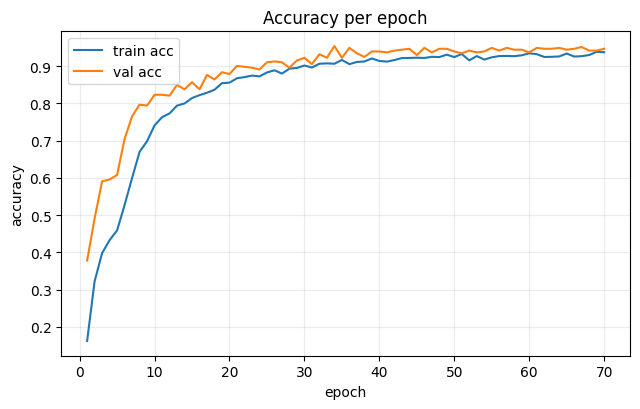

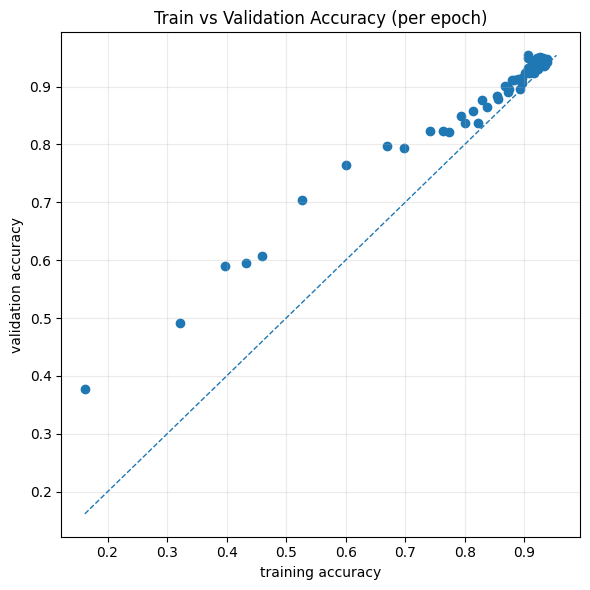

Avg gen gap (train - val): -0.0413   |   Max gap: -0.0020


In [19]:
# === ACCURACY PLOTS: line (per epoch) + XY (train vs val) ===

import os, sys, subprocess
from pathlib import Path

# make sure matplotlib/pandas are available (installs once if missing)
try:
    import matplotlib.pyplot as plt
    import pandas as pd
except ModuleNotFoundError:
    Path("C:/t/pip").mkdir(parents=True, exist_ok=True)
    os.environ["TMP"]=r"C:\t"; os.environ["TEMP"]=r"C:\t"; os.environ["PIP_CACHE_DIR"]=r"C:\t\pip"
    subprocess.check_call([sys.executable,"-m","pip","install","--no-cache-dir","matplotlib","pandas"])
    import matplotlib.pyplot as plt
    import pandas as pd

OUT_DIR = (MODEL_DIR / "models") if "MODEL_DIR" in globals() else (Path("model/models") if Path("model").exists() else Path("models"))

# 1) get history (prefer in-memory; else load CSV saved by training cell)
hist = None
if "history" in globals() and isinstance(history, dict) and history.get("train_acc"):
    hist = history
elif (OUT_DIR/"training_history.csv").exists():
    df = pd.read_csv(OUT_DIR/"training_history.csv")
    cols = [c for c in ["train_acc","val_acc","train_loss","val_loss"] if c in df.columns]
    hist = {k: df[k].tolist() for k in cols}

if not hist or "train_acc" not in hist or "val_acc" not in hist:
    raise SystemExit("No accuracy history found. Run training (or save training_history.csv) first.")

epochs = range(1, len(hist["train_acc"])+1)

# 2) line chart: accuracy vs epoch
plt.figure(figsize=(6.5,4.2))
plt.plot(epochs, hist["train_acc"], label="train acc")
plt.plot(epochs, hist["val_acc"],   label="val acc")
plt.title("Accuracy per epoch")
plt.xlabel("epoch"); plt.ylabel("accuracy")
plt.legend(); plt.grid(True, alpha=0.25); plt.tight_layout()
plt.show()

# 3) XY scatter: train acc (X) vs val acc (Y) + y=x line
import numpy as np
ta = np.array(hist["train_acc"], dtype=float)
va = np.array(hist["val_acc"],   dtype=float)

plt.figure(figsize=(6.0,6.0))
plt.scatter(ta, va)
mn = float(min(ta.min(), va.min()))
mx = float(max(ta.max(), va.max()))
plt.plot([mn, mx], [mn, mx], linestyle="--", linewidth=1)  # y = x reference
plt.xlabel("training accuracy")
plt.ylabel("validation accuracy")
plt.title("Train vs Validation Accuracy (per epoch)")
plt.grid(True, alpha=0.25); plt.tight_layout()
plt.show()

# (optional) quick text summary
gap = (ta - va)
print(f"Avg gen gap (train - val): {gap.mean():.4f}   |   Max gap: {gap.max():.4f}")


## 11) Test set evaluation

In [26]:
import torch
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# If you reload checkpoint here:
ckpt = torch.load(ckpt_path, map_location=device)
model.load_state_dict(ckpt["model"])
model = model.to(device)
model.eval()

TEST_DIR = DST / "test"
test_ds = NestedFreshSpeciesDataset(
    TEST_DIR,
    transform=val_tfms,
    class_to_idx=train_base.class_to_idx
)

test_loader = DataLoader(
    test_ds,
    batch_size=64,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

correct, total = 0, 0
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        out = model(x)
        pred = out.argmax(1)

        correct += (pred == y).sum().item()
        total += y.size(0)

print("✅ TRUE 12-class test accuracy:", correct / max(1, total))


✅ TRUE 12-class test accuracy: 0.9359605911330049


## 12) Export TorchScript (.pt) and ONNX (.onnx)

In [24]:
model.eval()
dummy = torch.randn(1,3,INPUT_SIZE,INPUT_SIZE).to(device)

# TorchScript
ts = torch.jit.trace(model, dummy)
ts_path = MODEL_DIR/'models'/'resnet50_torchvision_FEB.pt'
ts.save(str(ts_path))
print('Saved TorchScript ->', ts_path.resolve())


RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

## 13) EXPORTING TO ONNX FROM TOURCHSCRIPT .PT WITH A HUMAN READABLE TIMESTAMP

In [25]:
# --- ONNX export (legacy exporter) with timestamped filename (torchvision) ---
import torch
from pathlib import Path
from datetime import datetime

model.eval().cpu()
dummy = torch.randn(1, 3, INPUT_SIZE, INPUT_SIZE)  # CPU dummy

MODEL_DIR = Path('model') if Path('model').exists() else Path('.')
(MODEL_DIR/'models').mkdir(parents=True, exist_ok=True)

dt = datetime.now()
month_map = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",7:"Jul",8:"Aug",9:"Sept",10:"Oct",11:"Nov",12:"Dec"}
hour12 = dt.hour % 12 or 12
ampm = "am" if dt.hour < 12 else "pm"
stamp = f"{month_map[dt.month]}_{dt.day}_{hour12}-{dt.minute:02d}_{ampm}"

onnx_path = MODEL_DIR / "models" / f"resnet50_torchvision_{stamp}_FEB.onnx"

torch.onnx.export(
    model, dummy, str(onnx_path),
    input_names=['input'], output_names=['logits'],
    opset_version=13,
    do_constant_folding=True,
    training=torch.onnx.TrainingMode.EVAL,
    dynamo=False,
)
print("Saved ONNX ->", onnx_path.resolve())


Saved ONNX -> /kaggle/working/models/resnet50_torchvision_Feb_10_7-55_am_FEB.onnx


---
### Notes & References
- **d-li14** repo: README usage and imagenet training flags (cosine LR, 0.05 LR, 4e-5 WD, 224px) — we mirror those defaults here.
- **tonylins** repo: canonical MobileNetV2 module; we import it directly and set `num_classes`.
- Normalization uses ImageNet mean/std; resize/crop = 224.
- You can raise `EPOCHS`, use label smoothing, or RandAugment to push accuracy if needed.


In [ ]:
# Run this IN THE NOTEBOOK so it installs into the current kernel
import sys, subprocess
print("Kernel python:", sys.executable)
subprocess.check_call([sys.executable, "-m", "pip", "install", "-U",
                       "onnx>=1.15,<1.18", "onnxscript>=0.1.0,<0.2.0"])

In [ ]:
print("Num train classes =", len(train_base.classes))
print("Train classes =", train_base.classes)
print("Model fc out_features =", model.fc.out_features)

In [ ]:
x, y = next(iter(loaders["train"]))
out = model(x.to(device))
print("Output shape =", out.shape)   # should be [batch, 12]

In [ ]:
x, y = next(iter(loaders["train"]))
print("y min/max:", y.min().item(), y.max().item())
print("unique labels sample:", sorted(set(y.tolist()))[:20])

In [ ]:
ckpt = torch.load(ckpt_path, map_location="cpu")
print(ckpt["model"]["fc.weight"].shape)

In [ ]:
!cd /kaggle/working && zip -r models.zip models
